In [1]:
import math, numpy as np
import numpy.linalg as LA
from math import pi as π
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

## Pendulum problem, friction included
$$
    \ddot\theta =-{g\over\ell}\sin\theta - 2\alpha \dot\theta
$$

$x_1=\theta$, $x_2=\dot\theta$

\begin{align}
    \dot x_1 &= x_2\cr
    \dot x_2 &= -\frac{g}{\ell}\sin(x_1) - 2\alpha x_2\cr
\end{align}

In [2]:
g,ℓ = 9.81,.1
α = 0
def f(t,xx):
    x1,x2 = xx
    return [x2,-g*np.sin(x1)/ℓ - 2*α*x2]

In [3]:
atol,rtol = 1e-5,1e-5
y0 = [3*π/4,0.]

In [4]:
t0,t1 = 0,40
t_span = [t0,t1]
%time sol = solve_ivp(f,t_span,y0,method="RK45",atol=atol,rtol=rtol)

CPU times: user 100 ms, sys: 18.3 ms, total: 118 ms
Wall time: 97.4 ms


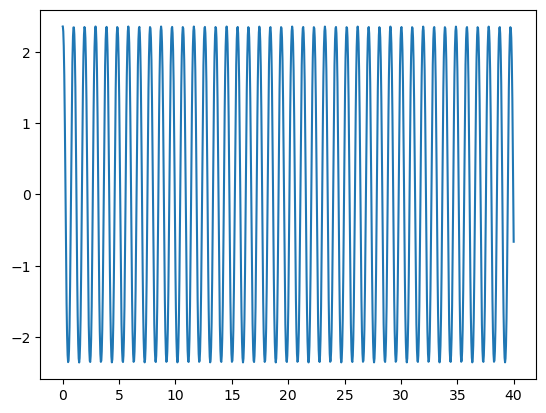

In [5]:
plt.plot(sol.t,sol.y[0])

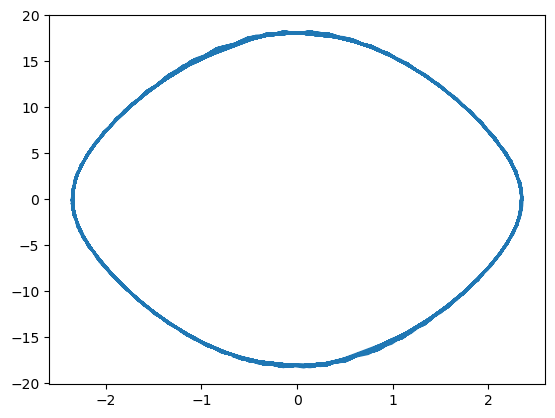

In [6]:
plt.plot(sol.y[0],sol.y[1])

CPU times: user 1min 8s, sys: 609 ms, total: 1min 9s
Wall time: 1min 9s


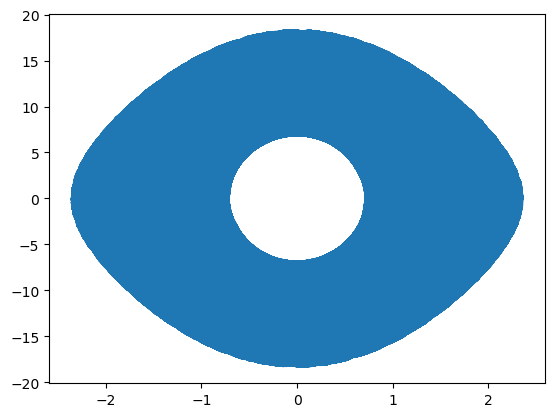

In [7]:
t0,t1 = 0,40_000
t_span = [t0,t1]
%time sol = solve_ivp(f,t_span,y0,method="RK45",atol=atol,rtol=rtol)
plt.plot(sol.y[0],sol.y[1])

CPU times: user 7.4 s, sys: 62.9 ms, total: 7.46 s
Wall time: 7.42 s


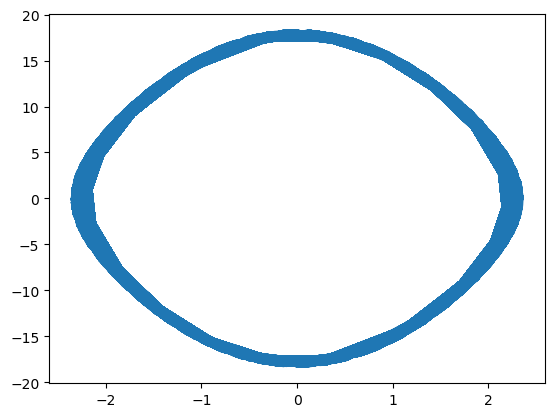

In [8]:
t0,t1 = 0,4_000
t_span = [t0,t1]
%time sol = solve_ivp(f,t_span,y0,method="RK45",atol=atol,rtol=rtol)
plt.plot(sol.y[0],sol.y[1])

CPU times: user 23.9 s, sys: 320 ms, total: 24.2 s
Wall time: 24 s


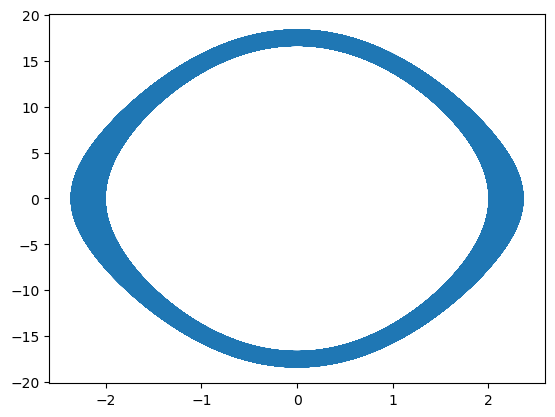

In [10]:
t0,t1 = 0,4_000
t_span = [t0,t1]
%time sol = solve_ivp(f,t_span,y0,method="RK23",atol=atol,rtol=rtol)
plt.plot(sol.y[0],sol.y[1])

CPU times: user 9.39 s, sys: 10.8 ms, total: 9.4 s
Wall time: 9.43 s


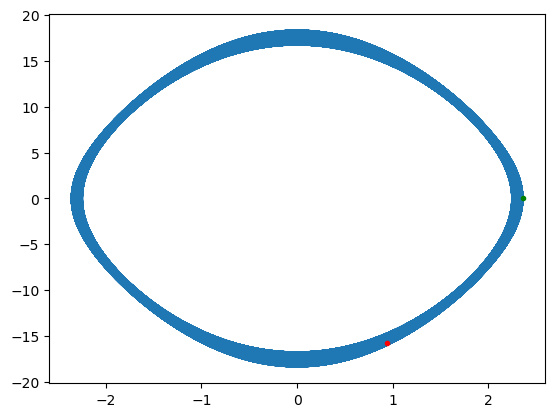

In [14]:
t0,t1 = 0,4_000
t_eval = np.linspace(t0,t1,50_000)
t_span = [t0,t1]
%time sol = solve_ivp(f,t_span,y0,method="DOP853",t_eval=t_eval,atol=atol,rtol=rtol)
plt.plot(sol.y[0],sol.y[1])
plt.plot(sol.y[0,0],sol.y[1,0],'g.')
plt.plot(sol.y[0,-1],sol.y[1,-1],'r.')

CPU times: user 10.2 s, sys: 31.8 ms, total: 10.3 s
Wall time: 10.3 s


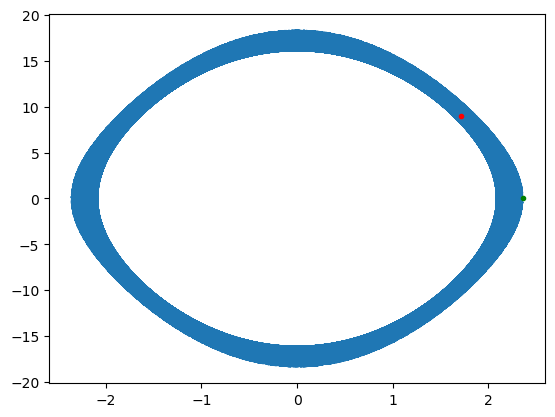

In [15]:
t0,t1 = 0,4_000
t_eval = np.linspace(t0,t1,50_000)
t_span = [t0,t1]
%time sol = solve_ivp(f,t_span,y0,method="RK45",t_eval=t_eval,atol=atol,rtol=rtol)
plt.plot(sol.y[0],sol.y[1])
plt.plot(sol.y[0,0],sol.y[1,0],'g.')
plt.plot(sol.y[0,-1],sol.y[1,-1],'r.')

CPU times: user 27.7 s, sys: 64.7 ms, total: 27.8 s
Wall time: 27.8 s


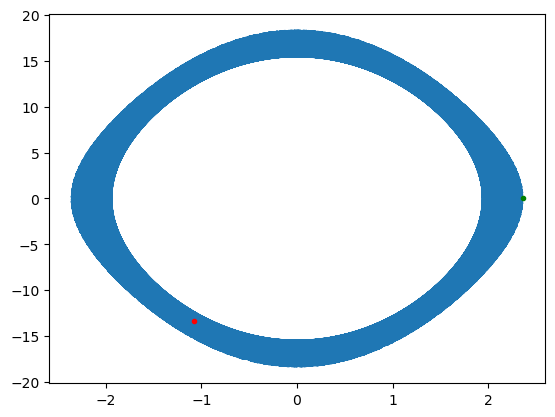

In [16]:
t0,t1 = 0,4_000
t_eval = np.linspace(t0,t1,50_000)
t_span = [t0,t1]
%time sol = solve_ivp(f,t_span,y0,method="RK23",t_eval=t_eval,atol=atol,rtol=rtol)
plt.plot(sol.y[0],sol.y[1])
plt.plot(sol.y[0,0],sol.y[1,0],'g.')
plt.plot(sol.y[0,-1],sol.y[1,-1],'r.')

CPU times: user 19.4 s, sys: 35.7 ms, total: 19.5 s
Wall time: 19.5 s


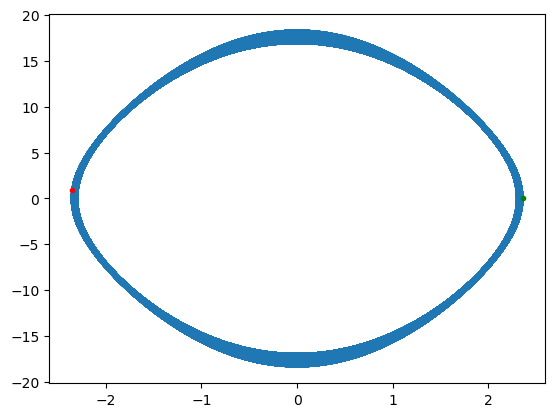

In [19]:
t0,t1 = 0,4_000
atol,rtol = 1e-7,1e-7
t_eval = np.linspace(t0,t1,50_000)
t_span = [t0,t1]
%time sol = solve_ivp(f,t_span,y0,method="RK45",t_eval=t_eval,atol=atol,rtol=rtol)
plt.plot(sol.y[0],sol.y[1])
plt.plot(sol.y[0,0],sol.y[1,0],'g.')
plt.plot(sol.y[0,-1],sol.y[1,-1],'r.')

### Lorenz equations
https://en.wikipedia.org/wiki/Lorenz_system
$$\eqalign{
\dot x & = \sigma(y-x)\cr
\dot y & = \rho x -y -xz\cr
\dot z & = xy-\beta z}
$$
Standard parameter values:
$$
    \sigma = 10,\qquad\beta = 8/3,\qquad\hbox{and}\qquad\rho = 28
$$

In [20]:
σ,β,ρ = 10.,8/3,28.
def lorenz(t,xyz):
    x,y,z = xyz
    return [σ*(y-x),ρ*x-y-x*z,x*y-β*z]

In [21]:
t0,t1 = 0,40
t_span = [t0,t1]
y0 = [1.,1.,1.]
atol,rtol = 1e-8,1e-8

In [22]:
%time sol = solve_ivp(lorenz,t_span,y0,method='RK45',atol=atol,rtol=rtol)

CPU times: user 258 ms, sys: 14 ms, total: 272 ms
Wall time: 258 ms


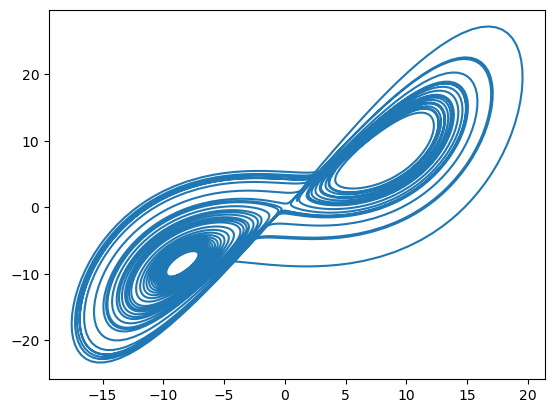

In [23]:
x,y,z = sol.y
plt.plot(x,y)